# 🔍 Satellite Chip Data Verification
업로드된 .npy 및 .json 파일을 확인하고 시각화합니다.

--- Data Info ---
Shape: (5, 32, 32) (Channels, Height, Width)
Metadata: {'cloud': 0.0, 'platform': 'landsat-7'}


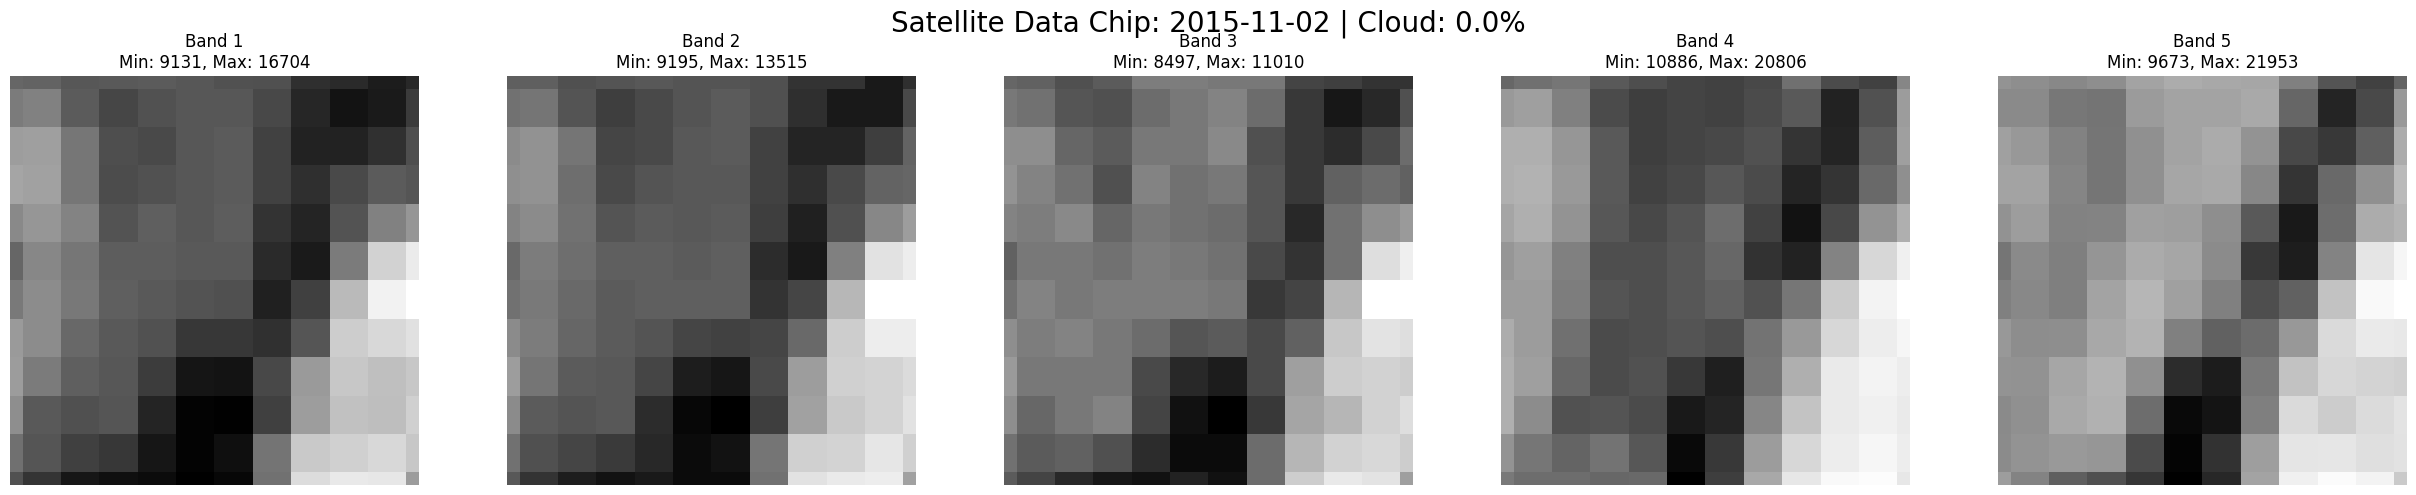

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import os

# 1. 데이터 경로 설정(Data Path Configuration)
# 사용자의 디렉토리 구조(Directory Structure) 반영
target_dir = 'rawData/chips/loc_-24.6951_27.4091'
target_date = '2015-11-02'
npy_path = os.path.join(target_dir, f'{target_date}.npy')
json_path = os.path.join(target_dir, f'{target_date}_meta.json')

# 2. 데이터 로드(Data Loading) 및 단위 테스트(Unit Test)
if not os.path.exists(npy_path):
    raise FileNotFoundError(f"Missing file: {npy_path}")

# 인터페이스 명세(Interface Specification) 강제: (5, 32, 32)
chip = np.load(npy_path)
with open(json_path, 'r') as f:
    meta = json.load(f)

print(f"--- Data Info ---")
print(f"Shape: {chip.shape} (Channels, Height, Width)")
print(f"Metadata: {meta}")

# 3. 채널별 시각화(Visualization)
# Landsat 7 데이터의 5개 밴드(Band)를 각각 출력
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i in range(5):
    # 각 채널의 통계치 계산
    band_min = chip[i].min()
    band_max = chip[i].max()
    
    axes[i].imshow(chip[i], cmap='gray')
    axes[i].set_title(f'Band {i+1}\nMin: {band_min}, Max: {band_max}')
    axes[i].axis('off')

plt.suptitle(f"Satellite Data Chip: {target_date} | Cloud: {meta.get('cloud')}%", fontsize=20)
plt.tight_layout()
plt.show()